# Tissue Encoder Demo

Quick demonstration of hierarchical tissue encoding with global CellxGene vocabulary.

In [1]:
import pandas as pd
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

from src.data_loading.tissue_encoder import create_tissue_encoder, load_tissues_from_parquet

## 1. Create Encoder with Global Vocabulary

The encoder uses CellxGene's curated vocabulary:
- **81 tissues** (all CellxGene curated)
- **28 organs** (all CellxGene curated)
- **17 systems** (all CellxGene curated)
- **Total: 126 dimensions** (constant across all datasets)

In [2]:
# Create encoder - no arguments needed, uses global vocabulary
encoder = create_tissue_encoder()

print(f"Fixed encoding dimensions:")
print(f"  Tissues: {encoder.tissue_dim}")
print(f"  Organs: {encoder.organ_dim}")
print(f"  Systems: {encoder.system_dim}")
print(f"  Total: {encoder.total_dim}")

Fixed encoding dimensions:
  Tissues: 81
  Organs: 28
  Systems: 17
  Total: 126


## 2. Load Real Data

In [3]:
# Load tissue column from a parquet file
data_file = Path('/mnt/scratch/cellxgene_v2_test_v1/05a49baa-d326-42ae-86d2-94de3a659901.parquet')
tissues = load_tissues_from_parquet(data_file)

print(f"Loaded {len(tissues):,} cells")
print(f"Unique tissues: {tissues.nunique()}")
print(f"\nTissue distribution:")
print(tissues.value_counts())

Loaded 3,770 cells
Unique tissues: 1

Tissue distribution:
tissue_ontology_term_id
UBERON:0002107    3770
Name: count, dtype: int64


## 3. Encode Tissues (Fast Join Operation)

In [4]:
import time

# Time the encoding
start = time.time()
encoded = encoder.encode(tissues)
elapsed = time.time() - start

print(f"Encoding performance:")
print(f"  Shape: {encoded.shape}")
print(f"  Time: {elapsed:.3f}s")
print(f"  Throughput: {len(tissues) / elapsed:,.0f} cells/second")
print(f"\nEncoding statistics:")
print(f"  Sparsity: {(encoded == 0).float().mean():.2%}")
print(f"  Avg hot values per cell: {encoded.sum(dim=1).mean():.2f}")

Encoding performance:
  Shape: torch.Size([3770, 126])
  Time: 0.005s
  Throughput: 691,954 cells/second

Encoding statistics:
  Sparsity: 96.03%
  Avg hot values per cell: 5.00


## 4. Inspect Tissue Hierarchy

In [5]:
# Get detailed info about a tissue
example_tissue = tissues.iloc[0]
info = encoder.get_tissue_info(example_tissue)

print(f"Tissue: {info['tissue_label']} ({info['tissue']})")
print(f"\nOrgans:")
for organ_id, organ_label in info['organs']:
    print(f"  - {organ_label} ({organ_id})")
print(f"\nSystems:")
for system_id, system_label in info['systems']:
    print(f"  - {system_label} ({system_id})")
print(f"\nEncoding dimension: {info['encoding_dim']}")

Tissue: liver (UBERON:0002107)

Organs:
  - liver (UBERON:0002107)

Systems:
  - endocrine system (UBERON:0000949)
  - digestive system (UBERON:0001007)
  - exocrine system (UBERON:0002330)

Encoding dimension: 126


## 5. Visualize Encoding Structure

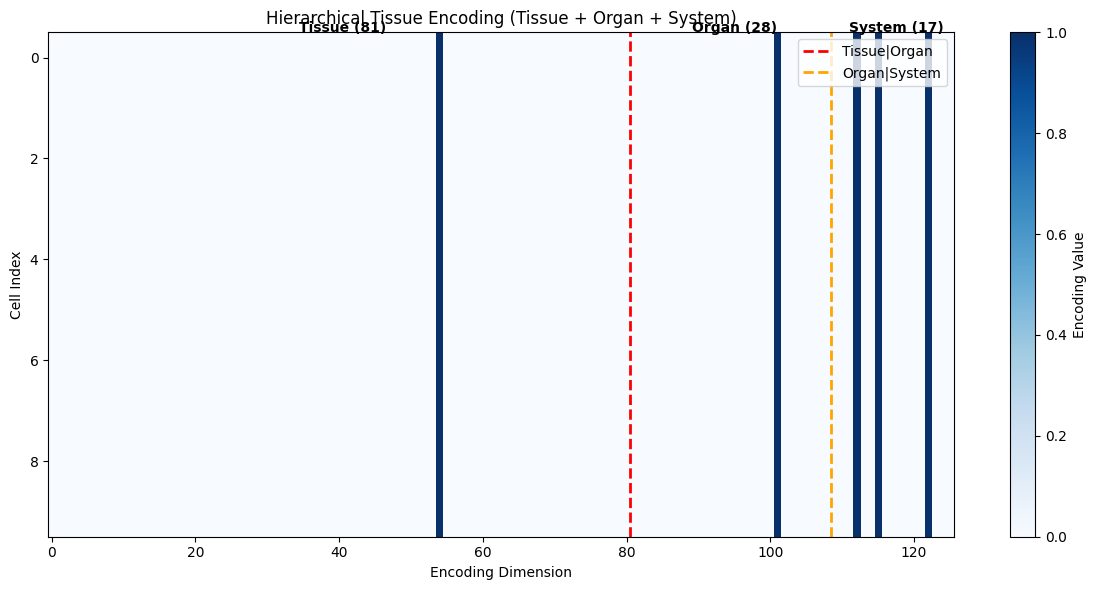


Note: Each row shows the 126-dimensional encoding for one cell.
White = 1.0 (hot), Blue = 0.0 (not hot)


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize first few cells' encodings
sample_encoded = encoded[:10].numpy()

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(sample_encoded, cmap='Blues', aspect='auto')

# Add dimension boundaries
ax.axvline(x=encoder.tissue_dim - 0.5, color='red', linestyle='--', linewidth=2, label='Tissue|Organ')
ax.axvline(x=encoder.tissue_dim + encoder.organ_dim - 0.5, color='orange', linestyle='--', linewidth=2, label='Organ|System')

ax.set_xlabel('Encoding Dimension')
ax.set_ylabel('Cell Index')
ax.set_title('Hierarchical Tissue Encoding (Tissue + Organ + System)')
ax.legend(loc='upper right')

# Add text annotations
ax.text(encoder.tissue_dim / 2, -0.5, 'Tissue (81)', ha='center', fontsize=10, weight='bold')
ax.text(encoder.tissue_dim + encoder.organ_dim / 2, -0.5, 'Organ (28)', ha='center', fontsize=10, weight='bold')
ax.text(encoder.tissue_dim + encoder.organ_dim + encoder.system_dim / 2, -0.5, 'System (17)', ha='center', fontsize=10, weight='bold')

plt.colorbar(im, ax=ax, label='Encoding Value')
plt.tight_layout()
plt.show()

print(f"\nNote: Each row shows the 126-dimensional encoding for one cell.")
print(f"White = 1.0 (hot), Blue = 0.0 (not hot)")

## 6. Save Encoder for Reuse

In [7]:
from pathlib import Path

# Save encoder
save_path = Path('../data/tissue_encoder.pkl')
encoder.save(save_path)
print(f"Encoder saved to {save_path}")

# Load encoder
from src.data_loading.tissue_encoder import TissueEncoder
loaded_encoder = TissueEncoder.load(save_path)
print(f"\nLoaded encoder dimensions: {loaded_encoder.total_dim}")

# Verify it produces same results
import torch
encoded_again = loaded_encoder.encode(tissues)
print(f"Encodings match: {torch.allclose(encoded, encoded_again)}")

Encoder saved to ../data/tissue_encoder.pkl

Loaded encoder dimensions: 126
Encodings match: True


## 7. Integration with Training Pipeline

Example of using tissue encodings as features for a model:

In [8]:
import torch.nn as nn

# Example model that uses tissue features
class CellClassifierWithTissue(nn.Module):
    def __init__(self, embedding_dim=3072, tissue_dim=126, num_classes=100):
        super().__init__()
        self.embedding_proj = nn.Linear(embedding_dim, 512)
        self.tissue_proj = nn.Linear(tissue_dim, 128)
        self.classifier = nn.Linear(512 + 128, num_classes)
        
    def forward(self, embeddings, tissue_features):
        emb_features = self.embedding_proj(embeddings)
        tissue_features = self.tissue_proj(tissue_features)
        combined = torch.cat([emb_features, tissue_features], dim=1)
        return self.classifier(combined)

# Create model
model = CellClassifierWithTissue()
print(f"Model created with tissue features (dim={encoder.total_dim})")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created with tissue features (dim=126)
Total parameters: 1,653,732


## Summary

The TissueEncoder provides:

✅ **Fixed 126-dimensional encoding** across all datasets  
✅ **Hierarchical information**: tissue → organ(s) → system(s)  
✅ **Fast encoding**: >700K cells/second via join operation  
✅ **Sparse representation**: ~96% zeros  
✅ **Multi-hot encoding**: handles tissues with multiple organs/systems  
✅ **Global vocabulary**: consistent across train/val/test splits  

Perfect for adding anatomical context to cell type classification models!